--- Model Evaluation ---
R-squared Score: 0.3122
RMSE: 4.9899



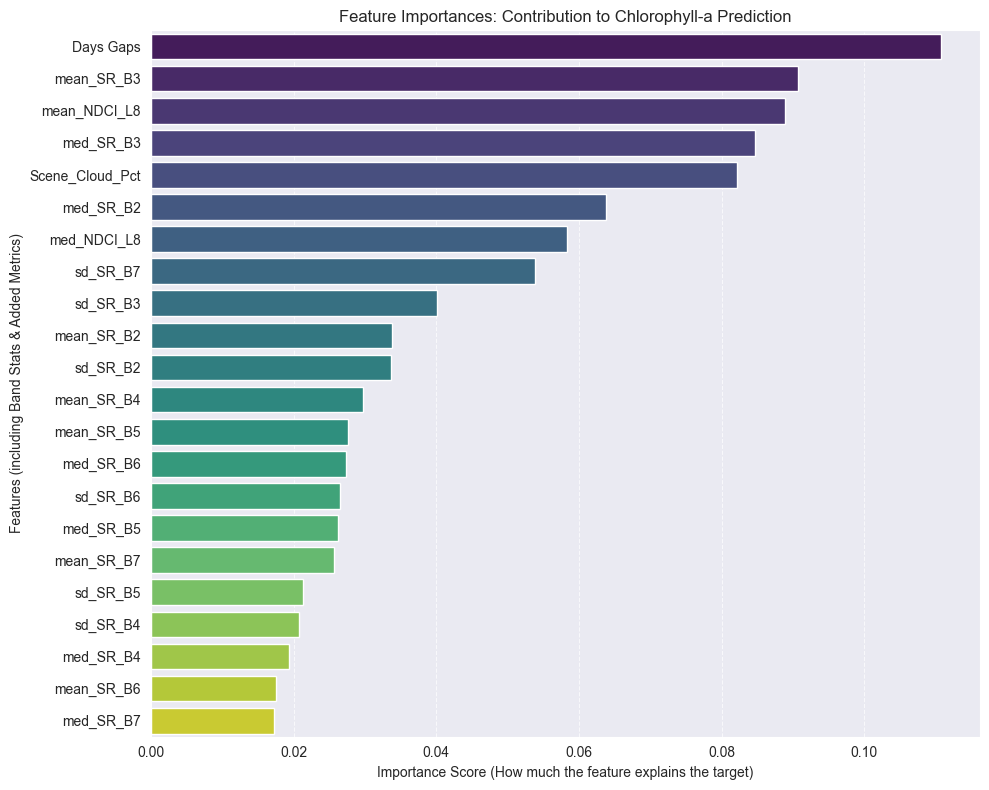

--- Feature Importance Ranking ---
        Feature  Importance
      Days Gaps    0.110667
     mean_SR_B3    0.090676
   mean_NDCI_L8    0.088875
      med_SR_B3    0.084662
Scene_Cloud_Pct    0.082183
      med_SR_B2    0.063797
    med_NDCI_L8    0.058333
       sd_SR_B7    0.053796
       sd_SR_B3    0.040169
     mean_SR_B2    0.033869
       sd_SR_B2    0.033649
     mean_SR_B4    0.029718
     mean_SR_B5    0.027703
      med_SR_B6    0.027323
       sd_SR_B6    0.026462
      med_SR_B5    0.026171
     mean_SR_B7    0.025678
       sd_SR_B5    0.021315
       sd_SR_B4    0.020805
      med_SR_B4    0.019310
     mean_SR_B6    0.017523
      med_SR_B7    0.017315


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('Tappan_L89_Bands_Thermal_NDCI_MNDWI_30mBuffer.csv')

target_col = 'Target Variable(Chlorophyll-a)'

original_features = df.columns[11:29].tolist()

additional_features = ['mean_NDCI_L8', 'med_NDCI_L8', 'Scene_Cloud_Pct', 'Days Gaps']
feature_cols = original_features + additional_features

data = df[[target_col] + feature_cols].dropna()

X = data[feature_cols]
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Evaluation ---")
print(f"R-squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}\n")

importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis',hue = 'Feature', legend=False)
plt.title('Feature Importances: Contribution to Chlorophyll-a Prediction')
plt.xlabel('Importance Score (How much the feature explains the target)')
plt.ylabel('Features (including Band Stats & Added Metrics)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("--- Feature Importance Ranking ---")
print(feature_importance_df.to_string(index=False))

# Here I have checked the individual R2 score for each of the column

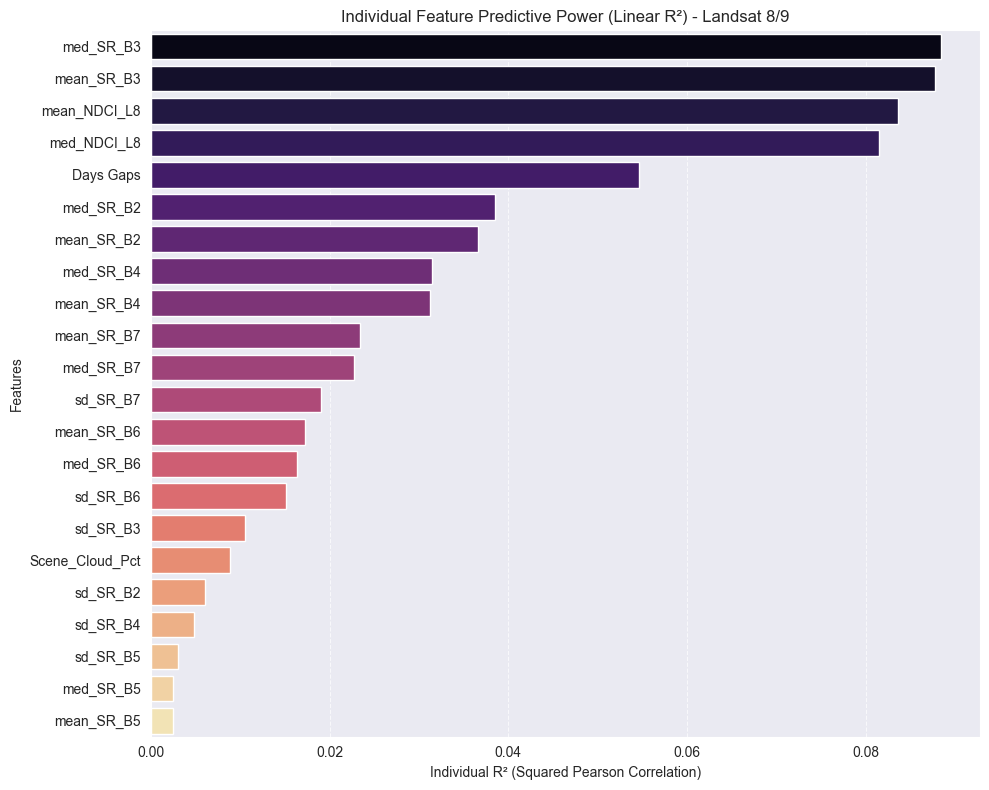

--- Individual Feature R2 Ranking ---
        Feature  Linear R2 (r²)
      med_SR_B3        0.088350
     mean_SR_B3        0.087780
   mean_NDCI_L8        0.083646
    med_NDCI_L8        0.081453
      Days Gaps        0.054631
      med_SR_B2        0.038466
     mean_SR_B2        0.036628
      med_SR_B4        0.031459
     mean_SR_B4        0.031291
     mean_SR_B7        0.023438
      med_SR_B7        0.022738
       sd_SR_B7        0.019021
     mean_SR_B6        0.017278
      med_SR_B6        0.016306
       sd_SR_B6        0.015091
       sd_SR_B3        0.010526
Scene_Cloud_Pct        0.008812
       sd_SR_B2        0.006087
       sd_SR_B4        0.004819
       sd_SR_B5        0.003013
      med_SR_B5        0.002540
     mean_SR_B5        0.002432


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

df = pd.read_csv('Tappan_L89_Bands_Thermal_NDCI_MNDWI_30mBuffer.csv')
target_col = 'Target Variable(Chlorophyll-a)'

original_features = df.columns[11:29].tolist()
additional_features = ['mean_NDCI_L8', 'med_NDCI_L8', 'Scene_Cloud_Pct', 'Days Gaps']
feature_cols = original_features + additional_features

data = df[[target_col] + feature_cols].dropna()

linear_r2_scores = []
for feat in feature_cols:
    r, _ = pearsonr(data[feat], data[target_col])
    linear_r2_scores.append({'Feature': feat, 'Linear R2 (r²)': r**2})

linear_r2_df = pd.DataFrame(linear_r2_scores).sort_values(by='Linear R2 (r²)', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Linear R2 (r²)', y='Feature', data=linear_r2_df, palette='magma',hue = 'Feature', legend=False)
plt.title('Individual Feature Predictive Power (Linear R²) - Landsat 8/9')
plt.xlabel('Individual R² (Squared Pearson Correlation)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("--- Individual Feature R2 Ranking ---")
print(linear_r2_df.to_string(index=False))

# other models testing

### data prep

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('Tappan_L89_Bands_Thermal_NDCI_MNDWI_30mBuffer.csv')
target_col = 'Target Variable(Chlorophyll-a)'

original_features = df.columns[11:29].tolist()
additional_features = ['mean_NDCI_L8', 'med_NDCI_L8', 'Scene_Cloud_Pct', 'Days Gaps']
feature_cols = original_features + additional_features

data = df[[target_col] + feature_cols].dropna()
X = data[feature_cols]
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data prepared! Training set size: {X_train_scaled.shape[0]}, Testing set size: {X_test_scaled.shape[0]}")
print(f"Total features used: {len(feature_cols)}")

Data prepared! Training set size: 117, Testing set size: 30
Total features used: 22


### Random Forest algorithm

--- 1. Random Forest ---
Overall Model R-squared: 0.3124
Overall Model RMSE: 4.9895



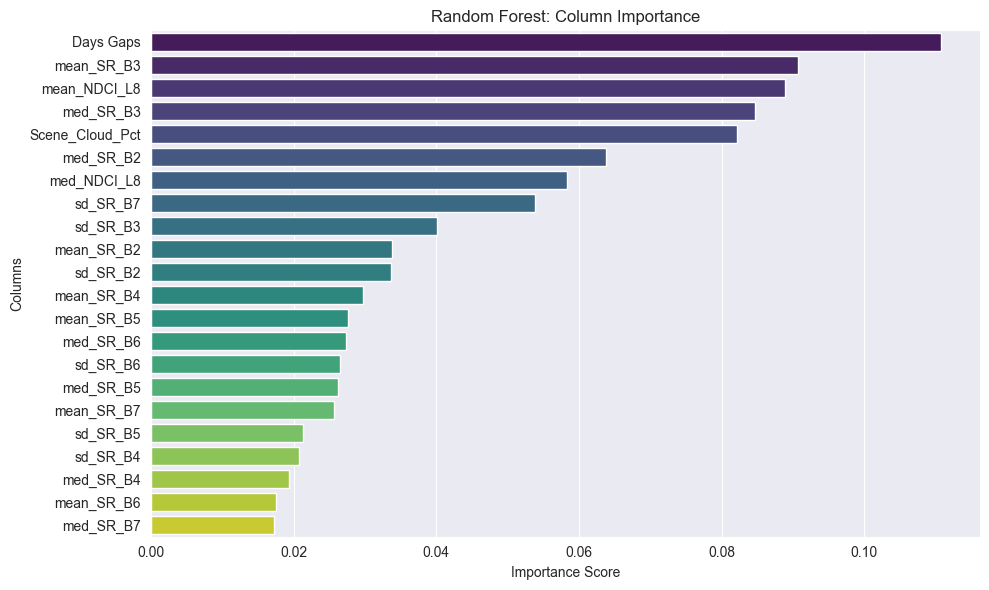

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("--- 1. Random Forest ---")
print(f"Overall Model R-squared: {r2_rf:.4f}")
print(f"Overall Model RMSE: {rmse_rf:.4f}\n")

rf_importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importances, palette='viridis',hue = 'Feature', legend=False)
plt.title('Random Forest: Column Importance')
plt.xlabel('Importance Score')
plt.ylabel('Columns')
plt.tight_layout()
plt.show()

### XGBoost

--- 3. ElasticNet ---
Overall Model R-squared: 0.2192
Overall Model RMSE: 5.3167



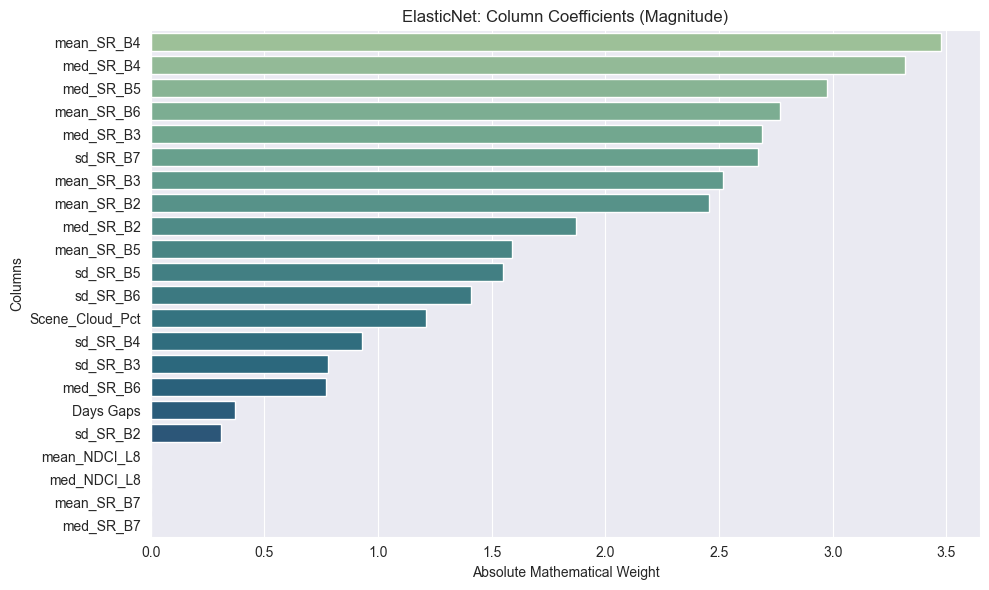

In [17]:
from sklearn.linear_model import ElasticNetCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

enet = ElasticNetCV(cv=5, max_iter=10000, random_state=42)
enet.fit(X_train_scaled, y_train)

y_pred_enet = enet.predict(X_test_scaled)
r2_enet = r2_score(y_test, y_pred_enet)
rmse_enet = np.sqrt(mean_squared_error(y_test, y_pred_enet))

print("--- 3. ElasticNet ---")
print(f"Overall Model R-squared: {r2_enet:.4f}")
print(f"Overall Model RMSE: {rmse_enet:.4f}\n")

enet_importances = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient_Magnitude': np.abs(enet.coef_)
}).sort_values(by='Coefficient_Magnitude', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Coefficient_Magnitude',
    y='Feature',
    data=enet_importances,
    palette='crest',
    hue='Feature',
    legend=False
)
plt.title('ElasticNet: Column Coefficients (Magnitude)')
plt.xlabel('Absolute Mathematical Weight')
plt.ylabel('Columns')
plt.tight_layout()
plt.show()

### ElasticNet Regression

--- 2. Gradient Boosting (Scikit-Learn) ---
Overall Model R-squared: 0.4177
Overall Model RMSE: 4.5914



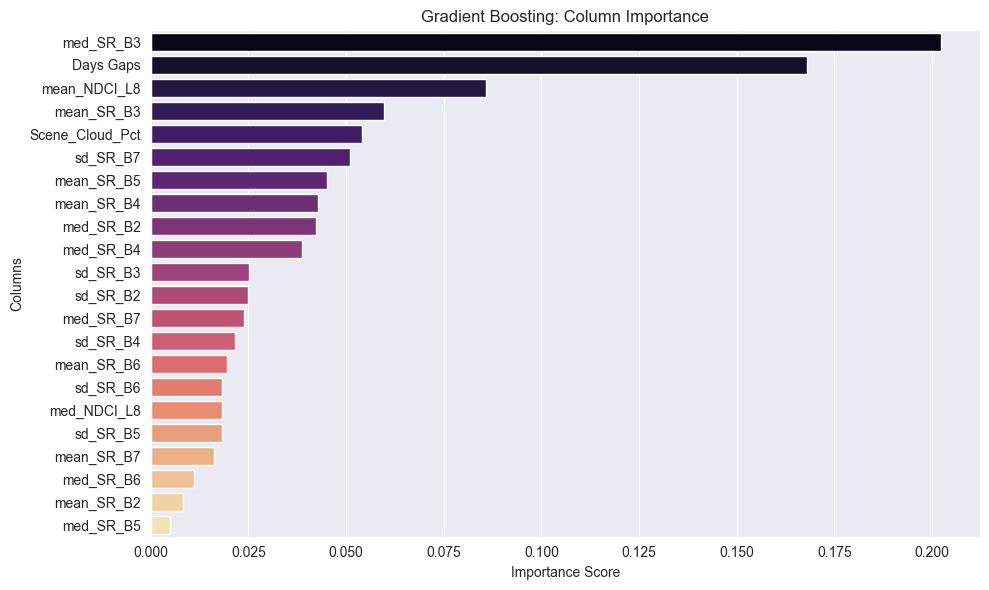

In [18]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)

y_pred_gb = gb.predict(X_test_scaled)
r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("--- 2. Gradient Boosting (Scikit-Learn) ---")
print(f"Overall Model R-squared: {r2_gb:.4f}")
print(f"Overall Model RMSE: {rmse_gb:.4f}\n")

gb_importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': gb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=gb_importances, palette='magma',hue = 'Feature', legend=False)
plt.title('Gradient Boosting: Column Importance')
plt.xlabel('Importance Score')
plt.ylabel('Columns')
plt.tight_layout()
plt.show()

### Support Vector Regression (SVR)

--- 4. Support Vector Regressor (SVR) ---
Overall Model R-squared: 0.2384
Overall Model RMSE: 5.2508

Calculating SVR column importance (this may take a few seconds)...


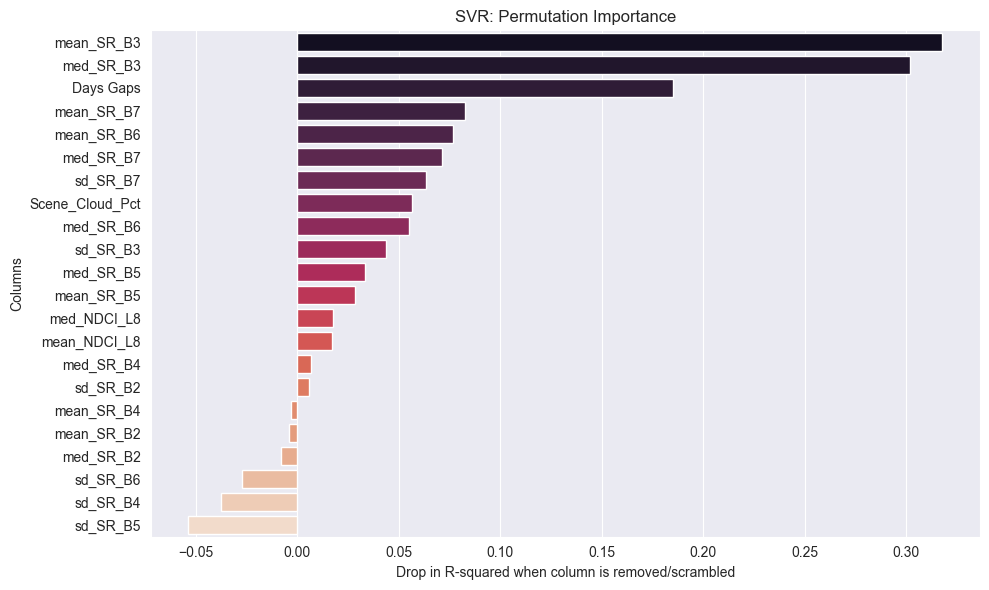

In [19]:
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance

svr = SVR(kernel='rbf', C=10, epsilon=0.1)
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)
r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

print("--- 4. Support Vector Regressor (SVR) ---")
print(f"Overall Model R-squared: {r2_svr:.4f}")
print(f"Overall Model RMSE: {rmse_svr:.4f}\n")

print("Calculating SVR column importance (this may take a few seconds)...")
svr_perm = permutation_importance(svr, X_test_scaled, y_test, n_repeats=10, random_state=42)

svr_importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Drop': svr_perm.importances_mean
}).sort_values(by='Importance_Drop', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance_Drop', y='Feature', data=svr_importances, palette='rocket',hue = 'Feature', legend=False)
plt.title('SVR: Permutation Importance')
plt.xlabel('Drop in R-squared when column is removed/scrambled')
plt.ylabel('Columns')
plt.tight_layout()
plt.show()

### Gaussian Process Regression (GPR)

--- 5. Gaussian Process Regression ---
Overall Model R-squared: 0.4286
Overall Model RMSE: 4.5482

Calculating GPR column importance (this may take a few seconds)...


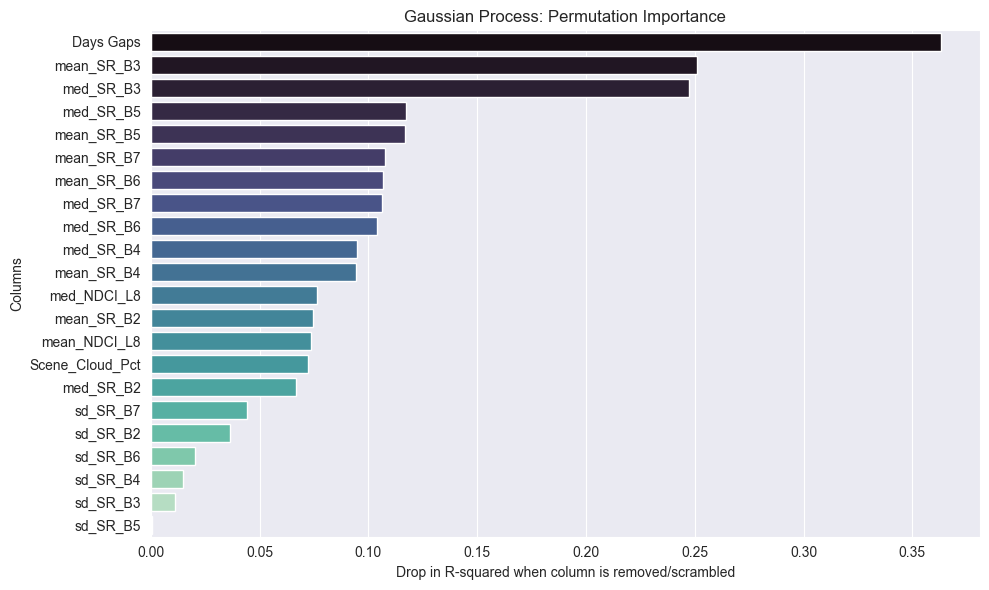

In [20]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.inspection import permutation_importance

kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42, normalize_y=True)
gpr.fit(X_train_scaled, y_train)

y_pred_gpr = gpr.predict(X_test_scaled)
r2_gpr = r2_score(y_test, y_pred_gpr)
rmse_gpr = np.sqrt(mean_squared_error(y_test, y_pred_gpr))

print("--- 5. Gaussian Process Regression ---")
print(f"Overall Model R-squared: {r2_gpr:.4f}")
print(f"Overall Model RMSE: {rmse_gpr:.4f}\n")

print("Calculating GPR column importance (this may take a few seconds)...")
gpr_perm = permutation_importance(gpr, X_test_scaled, y_test, n_repeats=10, random_state=42)

gpr_importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Drop': gpr_perm.importances_mean
}).sort_values(by='Importance_Drop', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance_Drop', y='Feature', data=gpr_importances, palette='mako',hue = 'Feature', legend=False)
plt.title('Gaussian Process: Permutation Importance')
plt.xlabel('Drop in R-squared when column is removed/scrambled')
plt.ylabel('Columns')
plt.tight_layout()
plt.show()